In [63]:
import jaxdem as jd
import jax
import jax.numpy as jnp
import numpy as np
from tqdm import tqdm

@jax.jit
def msd_for_lags(dp_com: jax.Array, lags: jax.Array) -> jax.Array:
    T = dp_com.shape[0]
    M = dp_com.shape[1]
    t = jnp.arange(T, dtype=lags.dtype)  # (T,)

    def msd_one(lag: jax.Array) -> jax.Array:
        # y[t] = dp_com[t + lag] (mod T) with a validity mask to drop wrapped terms
        idx = (t + lag) % T  # (T,)
        diff = dp_com[idx] - dp_com  # (T, M, dim)
        sq = jnp.sum(diff * diff, axis=-1)  # (T, M)

        valid = (t < (T - lag)).astype(dp_com.dtype)  # (T,)
        numer = jnp.sum(sq * valid[:, None])
        denom = (T - lag) * M
        return numer / denom

    return jax.vmap(msd_one)(lags)

def compute_msd(pos, batch_size = 256):
    # increase batch size for more throughput, decrease for lower peak memory
    # Compute MSD with a JIT-compiled kernel. To avoid doing "all at once", run lags in batches.
    t = np.arange(1, pos.shape[0] - 1, dtype=np.int32)
    msd = np.empty((t.size,), dtype=np.float64)

    for s in tqdm(range(0, t.size, batch_size)):
        lags = jnp.asarray(t[s : s + batch_size])
        msd[s : s + batch_size] = np.asarray(msd_for_lags(pos, lags))
    return msd, t

from file_management import load_arrs
from config import config2d as cfg
# state = jd.utils.h5.load('/home/mmccraw/dev/data/26-01-01/grant/sphere-fragilitiy/version-2/2d/phi-0.600000/final/state.h5')
# system = jd.utils.h5.load('/home/mmccraw/dev/data/26-01-01/grant/sphere-fragilitiy/version-2/2d/phi-0.600000/final/system.h5')
data = load_arrs(
    '/home/mmccraw/dev/data/26-01-01/grant/sphere-fragilitiy/version-2/2d/phi-0.600000/traj/data.h5'
)
pos = data['pos']
vel = data['vel']
mass = 1.0
sigma = 1.0
dim = 2

Ts, kes = [], []
ts, msds = [], []
for i in range(pos.shape[1]):
    msd, t = compute_msd(pos[:, i])
    ts.append(t * cfg.dt[i] * cfg.save_stride)
    msds.append(msd)
    ke = np.mean(np.sum(0.5 * np.sum(vel[:, i] ** 2, axis=-1) * mass, axis=-1))
    kes.append(ke)
    Ts.append(2 * ke / (dim * cfg.N))

100%|██████████| 79/79 [00:00<00:00, 120.33it/s]


1.0888247506747536e-05 9.814756177912395e-06 1e-05
9.698615151321614e-05 9.527599578648476e-05 0.0001
0.001004239674813377 0.0010323363460681963 0.001


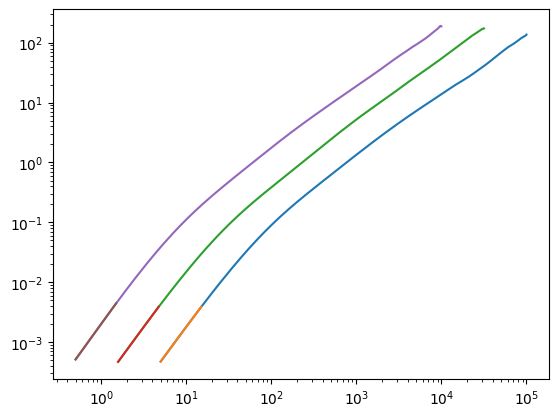

In [64]:
import matplotlib.pyplot as plt
for t, msd, T, T_true in zip(ts, msds, cfg.target_temperatures, Ts):

    ballistic_mask = t < (5e-2 / np.sqrt(T))
    x = np.log10(t[ballistic_mask])
    y = np.log10(msd[ballistic_mask])
    a, b = np.polyfit(x, y, deg=1)
    D_short = 10 ** b
    n = a

    plt.plot(t, msd)
    plt.plot(t[ballistic_mask], D_short * t[ballistic_mask] ** n)

    T_obs = D_short * mass / dim


    print(T_obs, T_true, T)
plt.xscale('log')
plt.yscale('log')